In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:
df = pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34990 entries, 0 to 34989
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             34990 non-null  int64  
 1   job             34990 non-null  object 
 2   marital         34990 non-null  object 
 3   education       34990 non-null  object 
 4   default         34990 non-null  object 
 5   housing         34990 non-null  object 
 6   loan            34990 non-null  object 
 7   contact         34990 non-null  object 
 8   month           34990 non-null  object 
 9   day_of_week     34990 non-null  object 
 10  duration        34990 non-null  int64  
 11  campaign        34990 non-null  int64  
 12  pdays           34990 non-null  int64  
 13  previous        34990 non-null  int64  
 14  poutcome        34990 non-null  object 
 15  emp.var.rate    34989 non-null  float64
 16  cons.price.idx  34989 non-null  float64
 17  cons.conf.idx   34989 non-null 

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


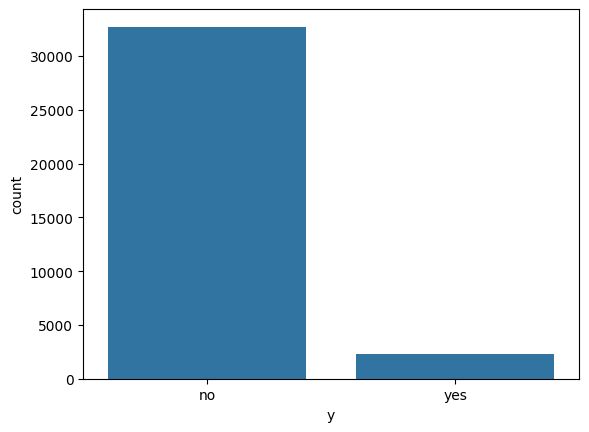

In [7]:
df['y'].value_counts()
sns.countplot(x='y', data=df)
plt.show()

In [8]:
df.replace("unknown", np.nan, inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_19655/472873001.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [9]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(name)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print()

In [14]:
# Temporarily impute NaNs in X_train and X_test for evaluation
# This is a localized fix for demonstration; the proper fix should be applied upstream in the data preprocessing.

# Create copies to avoid modifying global X_train, X_test directly
X_train_imputed = np.copy(X_train)
X_test_imputed = np.copy(X_test)

# Impute column-wise with the mean of each column from X_train
# Using X_train's mean for both train and test to avoid data leakage from X_test
for i in range(X_train_imputed.shape[1]):
    col_mean = np.nanmean(X_train_imputed[:, i])
    X_train_imputed[np.isnan(X_train_imputed[:, i]), i] = col_mean
    X_test_imputed[np.isnan(X_test_imputed[:, i]), i] = col_mean

def evaluate_model_imputed(name, model):
    model.fit(X_train_imputed, y_train) # Use imputed data
    y_pred = model.predict(X_test_imputed) # Use imputed data

    print(name)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print()

# Now call the models with the imputed data
evaluate_model_imputed("Logistic Regression", LogisticRegression())
evaluate_model_imputed("KNN", KNeighborsClassifier())
evaluate_model_imputed("SVM", SVC())
evaluate_model_imputed("Decision Tree", DecisionTreeClassifier())

Logistic Regression
Accuracy : 0.9371248928265219
Precision: 0.5799086757990868
Recall   : 0.2673684210526316
F1 Score : 0.3659942363112392

KNN
Accuracy : 0.933123749642755
Precision: 0.515695067264574
Recall   : 0.24210526315789474
F1 Score : 0.32951289398280803

SVM
Accuracy : 0.9364104029722778
Precision: 0.5974025974025974
Recall   : 0.1936842105263158
F1 Score : 0.29252782193958665

Decision Tree
Accuracy : 0.9202629322663618
Precision: 0.4158215010141988
Recall   : 0.43157894736842106
F1 Score : 0.42355371900826444



In [16]:
evaluate_model_imputed("Random Forest", RandomForestClassifier())
evaluate_model_imputed("Bagging", BaggingClassifier())
evaluate_model_imputed("AdaBoost", AdaBoostClassifier())
evaluate_model_imputed("Gradient Boosting", GradientBoostingClassifier())

Random Forest
Accuracy : 0.9378393826807659
Precision: 0.5714285714285714
Recall   : 0.3368421052631579
F1 Score : 0.423841059602649

Bagging
Accuracy : 0.9398399542726493
Precision: 0.5944055944055944
Recall   : 0.35789473684210527
F1 Score : 0.4467805519053876

AdaBoost
Accuracy : 0.93012289225493
Precision: 0.4583333333333333
Recall   : 0.16210526315789472
F1 Score : 0.23950233281493002

Gradient Boosting
Accuracy : 0.9405544441268934
Precision: 0.5924764890282131
Recall   : 0.39789473684210525
F1 Score : 0.4760705289672544



In [17]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

importance = model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(imp_df.head(10))

          Feature  Importance
10       duration    0.434834
0             age    0.112686
18      euribor3m    0.083242
1             job    0.057275
11       campaign    0.052803
3       education    0.049022
9     day_of_week    0.048426
2         marital    0.028241
17  cons.conf.idx    0.021887
5         housing    0.020954
